# Deep Learning - Exercise 1

## 🧪 Build and Document an Image Classifier with fastai

### **Goal**
In this part, you will **design, build, and document** a complete image-classification system using the **fastai** library.  
You will **define your own problem**, **collect or create your own dataset**, **train a model**, and **evaluate its performance**.  
Your solution will be submitted as a **GitHub repository**, along with a short **presentation** summarizing your workflow and results.

This exercise simulates a real-world applied deep learning pipeline—from idea to dataset to model to evaluation.

---

## 🎯 Learning Objectives
By completing this part, you will:

- Formulate a supervised learning problem and justify its relevance.
- Collect, construct, clean, and organize an image dataset.
- Build reproducible data pipelines using fastai.
- Train and fine-tune a modern deep-learning model.
- Critically evaluate performance using qualitative and quantitative tools.
- Communicate your process clearly in both code and presentation.

---

## 📦 Deliverables

### **1. GitHub Repository (the main submission)**
Your GitHub project must include:

#### **A. Jupyter Notebook (`project.ipynb`)**
This notebook should contain:

1. **Problem Definition**  
   - Description of the classes, use-case, and motivation  
   - Expected challenges  

2. **Dataset Creation and Preparation**  
   - How you collected the images  
   - Cleaning and filtering steps  
   - Final dataset structure (document with code or screenshots)

3. **Data Loading in fastai**  
   - `ImageDataLoaders` or `DataBlock`  
   - Example batches with `show_batch()`

4. **Model Training**  
   - Transfer learning setup  
   - Fine-tuning  
   - Training curves

5. **Evaluation**  
   - Confusion matrix  
   - `plot_top_losses`  
   - Examples of correct and incorrect predictions  
   - Discussion of model weaknesses (if there are any)


---

#### **B. Dataset**
Your dataset should be:

- Stored inside the repo **or** downloaded automatically with code  
- Organized into class-named folders  
- At least **100 images per class**

If using external sources, please give correct citation.

Don't make the dataset too big, training the model should not take too long.

---

### **2. Presentation (8–12 slides)**
Your presentation must cover:

1. **Problem Definition**  
   - Why you chose this problem  
   - What are the classes?  

2. **Data Collection Process**  
   - Sources, steps, difficulties  
   - Dataset size and examples  

3. **Model Pipeline**  
   - fastai approach  
   - Architecture chosen (e.g., ResNet34)  
   - Training details  

4. **Results**  
   - Accuracy, confusion matrix  
   - What the model learned / struggled with  

5. **Challenges Encountered**  
   - Noisy labels, class imbalance, unexpected behavior  

---

## 📤 How to Submit
Submit **only** your presentation, including a link to your GitHub repository, through the course system.

Your repo should contain:
- The notebook  
- The dataset (or download script)  

No additional files will be accepted outside GitHub.

---

This assignment is designed to reflect the real-world workflow of applied ML research and industry practice.  
Choose a problem you find meaningful—and have fun exploring!


In [ ]:
!pip install -U fastai

**Problem Definition**

 A binary classification problem that classifies a given photo of a dog to one of two breeds - Beagle and Boxer.

As we mentioned in the PowerPoint presentation, we have deceided to select this problem because we were looking to integrate our love of dogs into the task, and so we have deceided to create a simple classification task between two breeds of dogs that we like that resemble each other.

We expect to encounter problems finding quality data and labeling it accordingly.


**Dataset Creation and Preperation**


After searching the web for a short while for quality data that is also easy to manipulate programmatically- we have found the OXFORD-IIIT PET Dataset that can be accessed using fastai.
The dataset contains a few thousands of photos of cats and dogs (among them Beagles and Boxers) that are named according to the breed of the pet and according to the specimen (name starts in capital letter = cats, otherwise dogs.)- so the task of getting the data, filtering it and labeling it correctly is extreamly easier with this dataset.

As the code in the following bracket suggests- the data can be downloaded and unzipped programatically, so with 2 lines we could manipulate the entire data object.
As for filtering- we used Python tools to filter the data by its name. Every beagle and boxer (and only them) have that string in their name, so we wrote a specific parsing function to sort out the specific breeds from the entire dataset.

The final data object we used is a mix of Beagle and Boxer images that add up to 400 photos in total - 200 each.

We used the DataBlocks object to load the data to give to the learning model, and given an additional method that gets a photo and extracts the correct tag from it's name, in order to classify the photos to classes correctly.


As mentioned in the presentation- we have created a vision_learner object, gave it the data and set the parameters (resnet18 for the network and MSE for error measurements), set the fine tuning parameter to 1 to avoid over-fitting and run the code.

The results can be found in the presentation as well as in the output of the following code bracket.

Total files found: 7390
Selected (Beagle/Boxer): 400




epoch,train_loss,valid_loss,error_rate,time
0,0.763104,0.019583,0.000000,01:11


epoch,train_loss,valid_loss,error_rate,time
0,0.120983,0.009272,0.000000,01:30


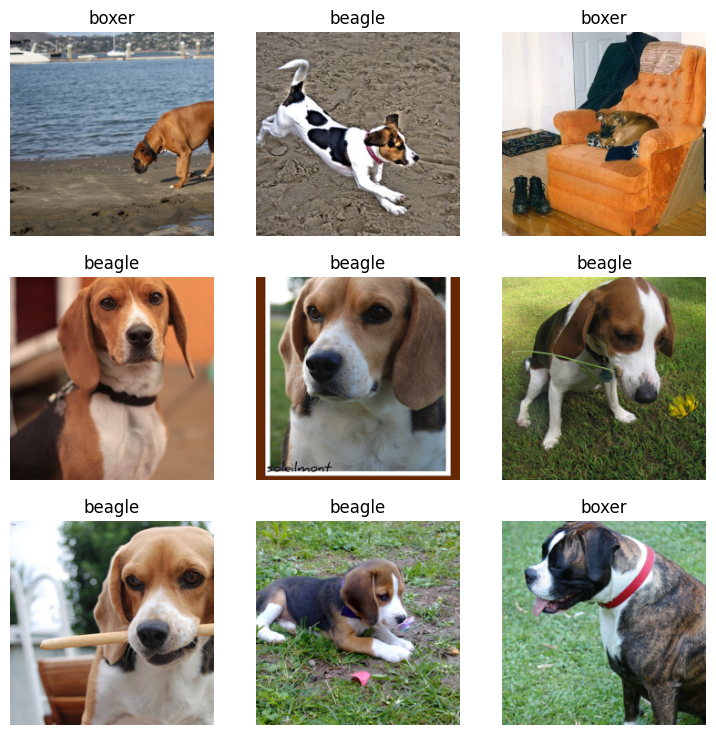

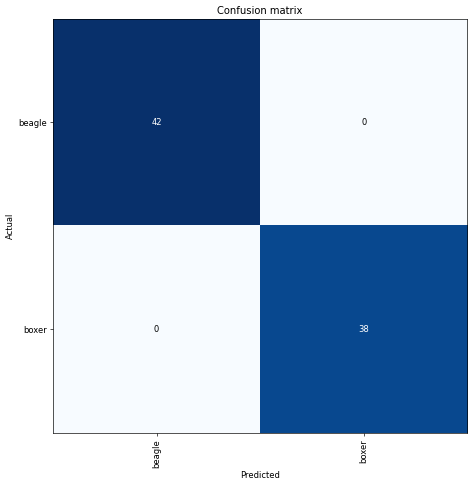

In [3]:
from fastai.vision.all import *
import random

# DATA_SIZE = 500
# IS_SIZE_LIMITED = False
CLASSES = ['beagle', 'boxer']

# print(URLs.PETS)
path = untar_data(URLs.PETS)
fnames = get_image_files(path/"images")
print(f"Total files found: {len(fnames)}")

selected_files = [f for f in fnames if any(breed in f.name.lower() for breed in CLASSES)]

print(f"Selected (Beagle/Boxer): {len(selected_files)}")

print("\n")
random.seed(42)
random.shuffle(selected_files)

# if IS_SIZE_LIMITED:
 #   limit = min(DATA_SIZE, len(selected_files))
  #  selected_files = selected_files[:limit]
   # print(f"Training on subset of: {len(selected_files)}")

def get_breed_label(x):
    return x.name.split('_')[0].lower()

dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_y=get_breed_label,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(224)
)

dls = dblock.dataloaders(selected_files)
dls.show_batch()

learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(1)

print("\n\n")

interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(8,8), dpi=60)